In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import pickle
from scipy.optimize import brentq

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

In [2]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):
    
    current_directory = os.getcwd()
    if current_directory.endswith(directory):
        pass
    else:
        os.chdir(directory)
    #initilize data list
    nematic_parameter = np.zeros(len(aspect_ratios))
    biaxiality = np.zeros(len(aspect_ratios))
    theta_d = np.zeros(len(aspect_ratios))
    phi = np.zeros(len(aspect_ratios))
    bin_centers = np.zeros((len(aspect_ratios), 100))
    pdf_data = np.zeros((len(aspect_ratios), 100)) 
    U_fitted = np.zeros(len(aspect_ratios))
    phi_fluctuations = np.zeros(len(aspect_ratios))
    D_r = np.zeros(len(aspect_ratios))
    shear_rate = np.zeros(len(aspect_ratios))
    rmse = np.zeros(len(aspect_ratios))
    n1_diff = np.zeros(len(aspect_ratios))
    n2_diff = np.zeros(len(aspect_ratios))
    p_yy = np.zeros(len(aspect_ratios))
    p_xy = np.zeros(len(aspect_ratios))
    S2_tensor = np.zeros((len(aspect_ratios), 3, 3))
    S4_tensor = np.zeros((len(aspect_ratios), 3, 3, 3, 3))
    strains = np.zeros((len(aspect_ratios), 3200))
    S2_over_time = np.zeros((len(aspect_ratios), 3200))
    biaxiality_over_time = np.zeros((len(aspect_ratios), 3200))
    angle_over_time = np.zeros((len(aspect_ratios), 3200))
    times = np.zeros((len(aspect_ratios), 510))
    oacf = np.zeros((len(aspect_ratios), 510))
    tau_r = np.zeros(len(aspect_ratios))
    A_infty = np.zeros(len(aspect_ratios))
    omega = np.zeros((len(aspect_ratios), 3))
    screening_jeffrey = np.zeros(len(aspect_ratios))
    error_screening = np.zeros(len(aspect_ratios))
    theta_bins = np.zeros((len(aspect_ratios), 15))
    omega_bins = np.zeros((len(aspect_ratios), 15))
    std_omega_bins = np.zeros((len(aspect_ratios), 15))

    for idx, ap in enumerate(aspect_ratios):
        filename = f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl'
        if os.path.exists(filename):
            with open(filename, 'rb') as file:
                file_data = pickle.load(file)
                bin_centers[idx, :] = file_data['bin_centers']
                pdf_data[idx, :] = file_data['f_data']
                nematic_parameter[idx] = file_data['nematic_order_parameter']
                biaxiality[idx] = file_data['biaxiality']
                theta_d[idx] = file_data['theta_d']
                U_fitted[idx] = file_data['U_fitted']
                phi[idx] = file_data['phi']
                phi_fluctuations[idx] = file_data['phi_fluct']
                D_r[idx] = file_data['D_r']
                shear_rate[idx] = file_data['shear_rate']
                rmse[idx] = file_data['rmse_fit']
                n1_diff[idx] = file_data['Nx_diff']
                n2_diff[idx] = file_data['Nz_diff']
                p_yy[idx] = file_data['p_yy']
                p_xy[idx] = file_data['p_xy']
                S2_tensor[idx, :, :] = file_data['nematic_tensor']
                S4_tensor[idx, :, :, :, :] = file_data['S4']
                strains[idx, :len(file_data['strains'])] = file_data['strains'] # zeros in the end
                S2_over_time[idx, :len(file_data['strains'])] = file_data['S2_over_time']
                biaxiality_over_time[idx, :len(file_data['strains'])] = file_data['biaxility_over_time']
                angle_over_time[idx, :len(file_data['strains'])] = file_data['angle_over_time']
                times[idx, :len(file_data['times'])] = file_data['times']
                oacf[idx, :len(file_data['times'])] = file_data['oacf']
                tau_r[idx] = file_data['tau_r']
                A_infty[idx] = file_data['A_infty']
                omega[idx, :] = file_data['ave_omega']
                screening_jeffrey[idx] = file_data['screening_jeffrey']
                error_screening[idx] = file_data['error_screening']
                theta_bins[idx, :] = file_data['theta_bins']
                omega_bins[idx, :] = file_data['omega_bins']
                std_omega_bins[idx, :] = file_data['std_omega_bins']


    os.chdir('..') # return to the original directory
    return (bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted,
             phi, phi_fluctuations, D_r, shear_rate, rmse, n1_diff, n2_diff, p_yy, p_xy,
               S2_tensor, S4_tensor, strains, S2_over_time, times, oacf, tau_r, A_infty,
                omega, screening_jeffrey, error_screening, angle_over_time, 
                theta_bins, omega_bins, std_omega_bins, biaxiality_over_time)

def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)

def P4(x):
    """Calculates the fourth Legendre polynomial, P₄(x)."""
    return 0.125 * (35 * x**4 - 30 * x**2 + 3)

def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)
    
    legendre_term = P2(cos_thetas)
    
    numerator = np.exp(S * U * legendre_term)
    
    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)
    
    return numerator / denominator

def fit_equilibrium_ODF_P4(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using both P₂ and P₄ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄) / Z
    """
    S2, S4 = order_params
    U2, U4 = interaction_params
    cos_thetas = np.cos(thetas)
    
    potential = U2 * S2 * P2(cos_thetas) + U4 * S4 * P4(cos_thetas)
    numerator = np.exp(potential)
    
    # Normalization Z = ∫ exp(...) sin(θ) dθ dφ
    integrand = numerator * np.sin(thetas)
    # Integral over dθ from 0 to π/2, then multiply by 2 (for 0 to π) and 2π (for φ)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)
    
    return numerator / denominator

def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 1): return r"$\pi$"
    elif np.isclose(frac, 0.5): return r"$\pi/2$"
    else: return fr"${frac:.2f}\pi$"

### P_2 only approximation

In [14]:
def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan


def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def compute_polar_pdf(theta_array, n_bins=100):
    """
    Compute the normalized PDF of polar angles theta_array over [0, pi],
    accounting for spherical geometry (sin(theta) weighting).
    """
    # Bin edges and centers
    bins = np.linspace(0, np.pi/2, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    delta_theta = bins[1] - bins[0]

    # Histogram of theta values
    counts, edges = np.histogram(theta_array, bins=bins)

    # Weight for spherical coordinates (sin(theta))
    sin_theta = np.sin(centers)

    # Normalize to get PDF f(theta), such that:
    # 2π ∫ f(θ) sin(θ) dθ = 1
    pdf = counts / (4 * np.pi * sin_theta * delta_theta * len(theta_array))

    return pdf, edges

def compute_rmse_error(measured_pdf, Us, S_2, bin_centers, d_theta):
    """
    Compute the Root Mean Square Error (RMSE) between the measured PDF and model PDF.
    """

    model = lambda thetas, U: fit_equilibrium_ODF(thetas, S_2, Us) 

    wsse = np.sum((measured_pdf - model(bin_centers, Us))**2)
              #* np.sin(bin_centers) * d_theta)
    rmse_sphere = np.sqrt(wsse / 2)

    return rmse_sphere


### P_2 and P_4 approximation

In [15]:
def calculate_S2_S4_from_distribution_p4(thetas, interaction_params, order_params_guess):
    """
    For a given set of interaction strengths (U₂, U₄) and a guessed
    set of order parameters (S₂_guess, S₄_guess), this function
    calculates the resulting order parameters by averaging P₂(cosθ)
    and P₄(cosθ) over the corresponding equilibrium distribution.
    """
    U2, U4 = interaction_params
    S2_guess, S4_guess = order_params_guess
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    potential = U2 * S2_guess * P2(cos_thetas) + U4 * S4_guess * P4(cos_thetas)
    numerator = np.exp(potential)
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P₂
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)

    # Integrand for the average of P₄
    integrand_P4 = P4(cos_thetas) * numerator * np.sin(thetas)
    P4_integral = np.trapezoid(integrand_P4, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0, 0.0
        
    # The new S₂ and S₄ are the correctly weighted averages
    S2_new = P2_integral / Z_integral
    S4_new = P4_integral / Z_integral
    
    return S2_new, S4_new

def solve_self_consistent_S2_S4_p4(interaction_params,
                                   initial_guesses=(0.8, 0.4),
                                   tol=1e-7,
                                   max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameters S₂ and S₄
    for a given set of interaction strengths (U₂, U₄).
    """
    S2, S4 = initial_guesses
    U2, U4 = interaction_params
    
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new, S4_new = calculate_S2_S4_from_distribution_p4(thetas,
                                                              interaction_params,
                                                              (S2, S4))
        
        # Check for convergence in *both* parameters
        if (np.abs(S2 - S2_new) < tol) and (np.abs(S4 - S4_new) < tol):
            return S2_new, S4_new  # Converged
            
        S2, S4 = S2_new, S4_new
        
    # If max_iter is reached, check if it's the isotropic state
    if (S2 < 0.05) and (np.abs(S4) < 0.05):
        return 0.0, 0.0
        
    # print(f"Warning: Self-consistency for U₂={U2:.2f}, U₄={U4:.2f} did not converge. "
    #       f"Returning last values: S₂={S2:.3f}, S₄={S4:.3f}")
    return S2, S4

def find_U_from_S2_S4_p4(target_order_params,
                         initial_U_guesses=(-3.0, -1.0),
                         tol=1e-7):
    """
    Finds the interaction strengths (U₂, U₄) that self-consistently
    produce a target set of order parameters (target_S₂, target_S₄).
    
    Uses a 2D root-finding algorithm.
    
    Args:
        target_order_params (tuple): (target_S₂, target_S₄).
        initial_U_guesses (tuple): An initial guess for (U₂, U₄).
        tol (float): The tolerance for the root-finding.

    Returns:
        numpy.ndarray: The self-consistent interaction strengths [U₂, U₄].
    """
    target_S2, target_S4 = target_order_params
    
    # Handle the trivial isotropic case
    if (target_S2 <= 0.01) and (np.abs(target_S4) <= 0.01):
        return np.array([0.0, 0.0])

    # Define the 2D objective function whose root we want to find.
    # The input `U_vec` is a numpy array [U₂, U₄].
    # The output is an error vector [error_S₂, error_S₄].
    def objective_func(U_vec):
        U2, U4 = U_vec
        interaction_params = (U2, U4)
        
        # Use the targets as the initial guess for the *inner* self-consistency
        # This speeds up the root-finding significantly.
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        error_S2 = S2_calc - target_S2
        error_S4 = S4_calc - target_S4
        
        return [error_S2, error_S4]

    try:
        # Use a robust 2D root-finder
        # 'lm' (Levenberg-Marquardt) is often a good choice.
        sol = root(objective_func, initial_U_guesses, method='lm', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the array [U₂, U₄]
        else:
            print(f"Warning: Root-finding for U's failed. Message: {sol.message}")
            return np.array([np.nan, np.nan])
            
    except Exception as e:
        print(f"Error during root-finding for U's: {e}")
        return np.array([np.nan, np.nan])

Number of colors: 4, Length of colormap: 256, Delta color: 85.0


/tmp/ipykernel_40870/4101312282.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


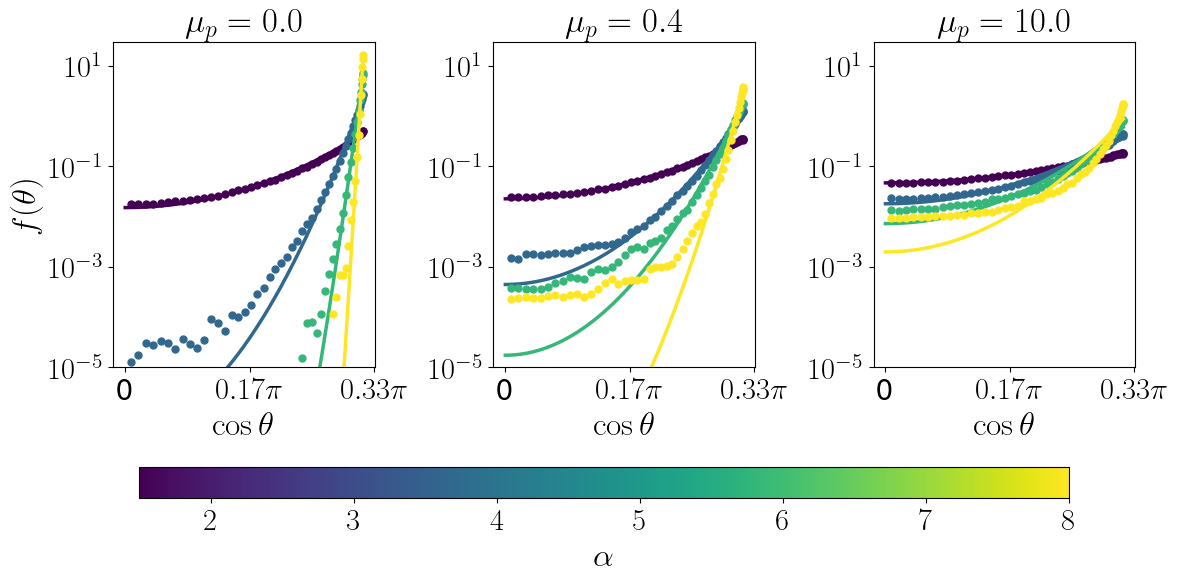

In [11]:
aspect_ratios = np.array([1.5, 3.0, 5.0, 8.0])

directory = "output_data_hertz_polydisperse"

thetas = np.linspace(0, np.pi / 2, 200)
cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
delta_color = np.floor(length_cmap / (num_colors-1))
print(f"Number of colors: {num_colors}, Length of colormap: {length_cmap}, Delta color: {delta_color}")
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]

I=0.1
cofs = [0.0, 0.4, 10.0]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(4 * num_cofs, 4))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

Us_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    (bin_centers, pdf_data, nematic_parameter, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
       rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
       strains, S2_over_time, times, oacf, tau_r, A_infty, 
       omega, screening_jeffrey, error_screening, angle_over_time,
         theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

    U_self_consistent = [find_U_from_S2(s2) for s2 in nematic_parameter]
    Us_self_consistents[cofs.index(cof), 0, :] = U_self_consistent

    for i, ap in enumerate(aspect_ratios):        
        
        fitted_odf = fit_equilibrium_ODF(thetas, nematic_parameter[i], U_self_consistent[i])
        # fitted_odf = fit_equilibrium_ODF(thetas, nematic_parameter[i], U_fitted[i])

        # Compute RMSE error between measured PDF and fitted ODF
        d_theta = bin_centers[i, 1] - bin_centers[i, 0]
        rmse_error = compute_rmse_error(pdf_data[i, :], U_self_consistent[i], nematic_parameter[i], bin_centers[i, :], d_theta)
        rmse_self_consistents[cofs.index(cof), 0, i] = rmse_error


        # Plot fitted ODF and PDF data
        ax.semilogy(np.cos(thetas), fitted_odf, label=f'$\\alpha={ap}$', linestyle='-', linewidth=2.5, color=colors[i])
        ax.semilogy(np.cos(bin_centers[i, ::2]), pdf_data[i, ::2], 'o', linestyle='', markersize=5, color=colors[i])
        
    ax.set_ylim(1e-5, 30)
    ax.set_xlabel('$\\cos \\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
sm.set_array([])  # Needed only for matplotlib < 3.1

# Add colorbar above the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes[0].set_ylabel('$f(\\theta)$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_Is_{I}_cos.png", dpi=300, bbox_inches='tight')
plt.show()

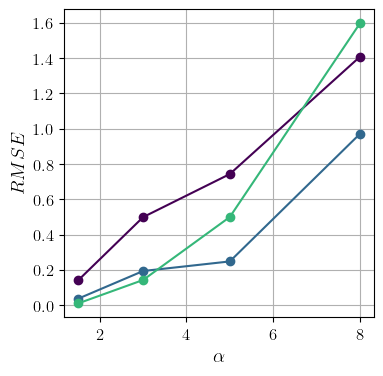

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        rmse_self_consistents[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$RMSE$")
ax.grid(True)
# plt.savefig(f"rmse_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


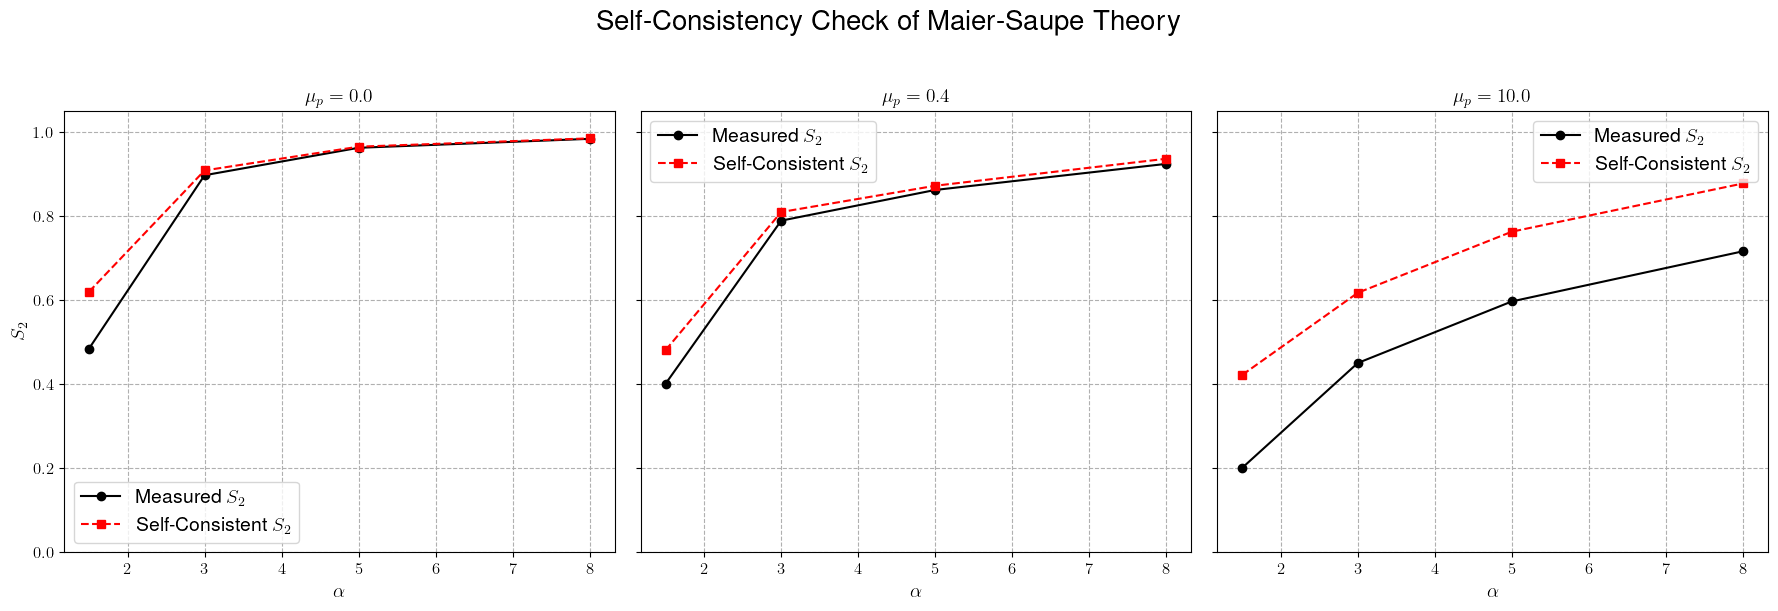

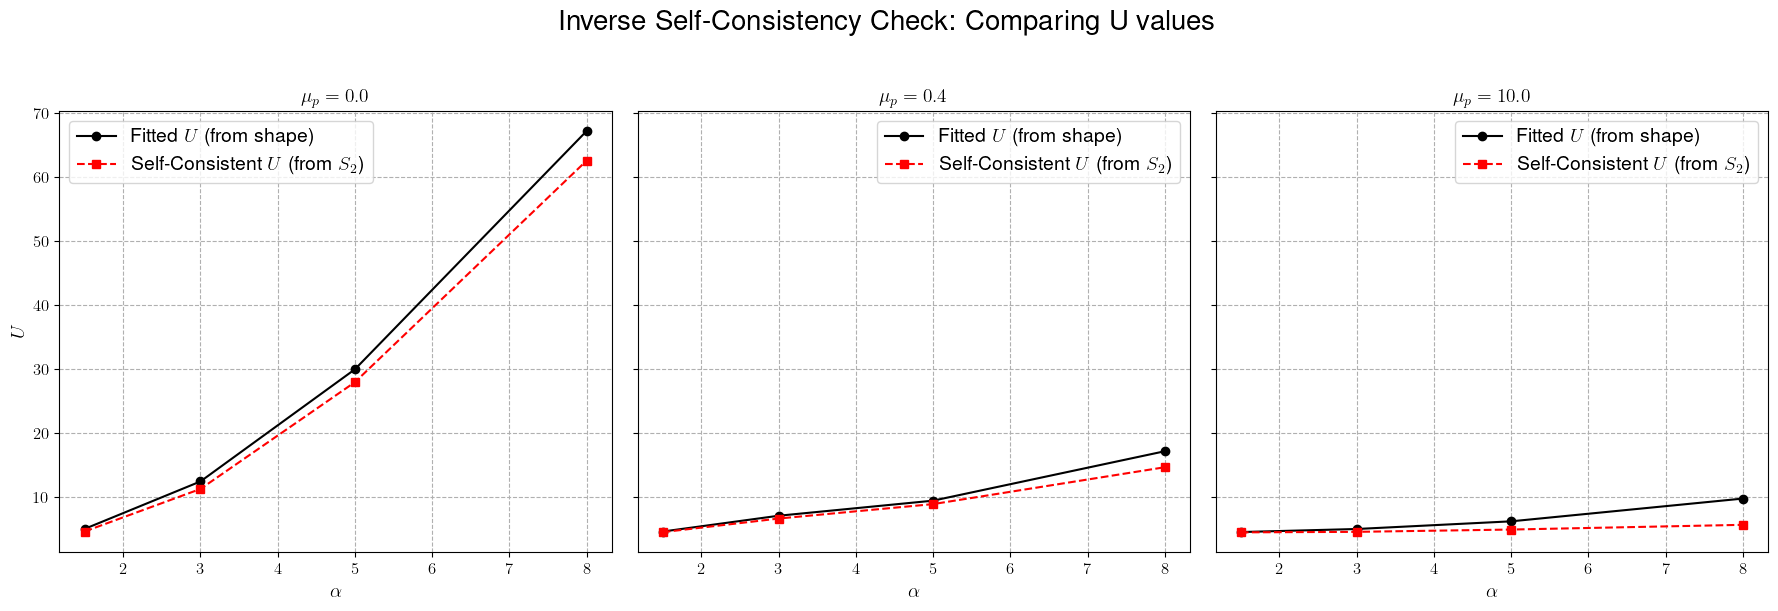

In [6]:
# compare the measured nematic order parameter with the self-consistent solution using U_fitted

# Create a new figure for the self-consistency check
fig_sc, axes_sc = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
if num_cofs == 1:
    axes_sc = [axes_sc]

fig_sc.suptitle('Self-Consistency Check of Maier-Saupe Theory', fontsize=20, y=1.02)

# Loop through each coefficient of friction
for ax, cof in zip(axes_sc, cofs):
    # Read the data for the current coefficient of friction
    # This call should be identical to the one in your main plotting loop
    (bin_centers, pdf_data, nematic_parameter, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
     rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
     strains, S2_over_time, times, oacf, tau_r, A_infty, 
     omega, screening_jeffrey, error_screening, angle_over_time,
     theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

    # For each aspect ratio, use the fitted U to solve for the self-consistent S2
    S2_self_consistent = [solve_self_consistent_S2(U) for U in U_fitted]

    # Plot the S2 measured directly from the simulation particle orientations
    ax.plot(aspect_ratios, nematic_parameter, 'o-', color='black', label='Measured $S_2$')
    
    # Plot the theoretical S2 that is self-consistent with the fitted U
    ax.plot(aspect_ratios, S2_self_consistent, 's--', color='red', label='Self-Consistent $S_2$')
    
    ax.set_title(f'$\\mu_p = {cof}$')
    ax.set_xlabel('$\\alpha$')
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--')
    ax.legend()

# Set common labels and finalize the plot
axes_sc[0].set_ylabel('$S_2$')
plt.tight_layout()
plt.savefig(f"self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
plt.show()

# Create a new figure for the inverse self-consistency check
fig_u, axes_u = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
if num_cofs == 1:
    axes_u = [axes_u]

fig_u.suptitle('Inverse Self-Consistency Check: Comparing U values', fontsize=20, y=1.02)

# Loop through each coefficient of friction
for ax, cof in zip(axes_u, cofs):
    # Read the data for the current coefficient of friction
    (bin_centers, pdf_data, nematic_parameter, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
     rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
     strains, S2_over_time, times, oacf, tau_r, A_infty, 
     omega, screening_jeffrey, error_screening, angle_over_time,
     theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

    # For each aspect ratio, use the measured S2 to find the self-consistent U
    U_self_consistent = [find_U_from_S2(s2) for s2 in nematic_parameter]

    # compute the nematic order parameter from the data of the distribution
    U_computed = [ find_S2

    # Plot the U obtained by fitting the distribution's shape
    ax.plot(aspect_ratios, U_fitted, 'o-', color='black', label='Fitted $U$ (from shape)')
    
    # Plot the theoretical U that is self-consistent with the measured S2
    ax.plot(aspect_ratios, U_self_consistent, 's--', color='red', label='Self-Consistent $U$ (from $S_2$)')
    
    ax.set_title(f'$\\mu_p = {cof}$')
    ax.set_xlabel('$\\alpha$')
    ax.grid(True, linestyle='--')
    ax.legend()

# Set common labels and finalize the plot
axes_u[0].set_ylabel('$U$')
plt.tight_layout()
plt.savefig(f"inverse_self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
plt.show()



In [7]:
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0]
Is = [0.001, 0.0046, 0.0022, 0.01, 0.046, 0.022, 0.1]
aspect_ratios = np.array([1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0])
# cofs=[0.0, 0.001]
Is=[0.1]
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0]


biaxiality = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
nematic_parameter = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
theta_d = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U_fitted = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phis = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phi_fluctuations = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
D_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
shear_rates = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
rmse = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n1_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n2_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_yy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_xy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3))
S4_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3, 3, 3))
# Initialize arrays to store strains, S2_over_time, times, and oacf
strains = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
S2_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
biaxiality_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
angle_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
times = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
oacf = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
tau_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
A_infty = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
# Initialize arrays for omega, screening_jeffrey, error_screening, and angle_over_time
omega = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3))
screening_jeffrey = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
error_screening = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
# 
theta_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
std_omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))

rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

loaded=False

try:
    with open(os.path.join(directory, "U_and_rmse_self_consistent.pkl"), 'rb') as f:
        data_loaded = pickle.load(f)
    Us_self_consistents = data_loaded['Us_self_consistents']
    rmse_self_consistents = data_loaded['rmse_self_consistents']
    print("Loaded saved data successfully.")
    loaded=True
except (FileNotFoundError, KeyError):
    print("U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...")
    Us_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))  # if you need this too

for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        (bin_centers, pdf_data, nematic_parameter_temp, biaxiality_temp, theta_d_temp,
          U_fitted_temp, phi_temp, phi_fluct_temp, D_r_temp, shear_rate_temp, 
          rmse_temp, n1_diff_temp, n2_diff_temp, p_yy_temp, p_xy_temp, 
          S2_tensor_temp, S4_tensor_temp, 
          strains_temp, S2_over_time_temp, times_temp, oacf_temp, tau_r_temp, A_infty_temp, 
          omega_temp, screening_jeffrey_temp, error_screening_temp, angle_over_time_temp,
            theta_bins_temp, omega_bins_temp, std_omega_bins_temp, biaxiality_over_time_temp
          ) = read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)
        
        for i_alpha in range(len(aspect_ratios)):
            biaxiality[i_cof, i_I, i_alpha] = biaxiality_temp[i_alpha]
            nematic_parameter[i_cof, i_I, i_alpha] = nematic_parameter_temp[i_alpha]
            theta_d[i_cof, i_I, i_alpha] = theta_d_temp[i_alpha]
            U_fitted[i_cof, i_I, i_alpha] = U_fitted_temp[i_alpha]
            phis[i_cof, i_I, i_alpha] = phi_temp[i_alpha]
            phi_fluctuations[i_cof, i_I, i_alpha] = phi_fluct_temp[i_alpha]
            D_r[i_cof, i_I, i_alpha] = D_r_temp[i_alpha]
            shear_rates[i_cof, i_I, i_alpha] = shear_rate_temp[i_alpha]
            rmse[i_cof, i_I, i_alpha] = rmse_temp[i_alpha]
            n1_diff[i_cof, i_I, i_alpha] = n1_diff_temp[i_alpha]
            n2_diff[i_cof, i_I, i_alpha] = n2_diff_temp[i_alpha]
            p_yy[i_cof, i_I, i_alpha] = p_yy_temp[i_alpha]
            p_xy[i_cof, i_I, i_alpha] = p_xy_temp[i_alpha]
            S2_tensor[i_cof, i_I, i_alpha, :, :] = S2_tensor_temp[i_alpha, :, :]
            S4_tensor[i_cof, i_I, i_alpha, :, :, :, :] = S4_tensor_temp[i_alpha, :, :, :, :]
            strains[i_cof, i_I, i_alpha, :len(strains_temp[i_alpha])] = strains_temp[i_alpha]
            S2_over_time[i_cof, i_I, i_alpha, :len(S2_over_time_temp[i_alpha])] = S2_over_time_temp[i_alpha]
            biaxiality_over_time[i_cof, i_I, i_alpha, :len(biaxiality_over_time_temp[i_alpha])] = biaxiality_over_time_temp[i_alpha]
            times[i_cof, i_I, i_alpha, :len(times_temp[i_alpha])] = times_temp[i_alpha]
            oacf[i_cof, i_I, i_alpha, :len(oacf_temp[i_alpha])] = oacf_temp[i_alpha]
            tau_r[i_cof, i_I, i_alpha] = tau_r_temp[i_alpha]
            A_infty[i_cof, i_I, i_alpha] = A_infty_temp[i_alpha]
            omega[i_cof, i_I, i_alpha, :] = omega_temp[i_alpha, :]
            screening_jeffrey[i_cof, i_I, i_alpha] = screening_jeffrey_temp[i_alpha]
            error_screening[i_cof, i_I, i_alpha] = error_screening_temp[i_alpha]
            angle_over_time[i_cof, i_I, i_alpha, :len(angle_over_time_temp[i_alpha])] = angle_over_time_temp[i_alpha]
            theta_bins[i_cof, i_I, i_alpha, :] = theta_bins_temp[i_alpha, :]
            omega_bins[i_cof, i_I, i_alpha, :] = omega_bins_temp[i_alpha, :]
            std_omega_bins[i_cof, i_I, i_alpha, :] = std_omega_bins_temp[i_alpha, :]
            if not loaded:
              U_self_consistent = [find_U_from_S2(s2) for s2 in nematic_parameter_temp]
              Us_self_consistents[i_cof, i_I, i_alpha] = U_self_consistent[i_alpha]
              d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]
              rmse_error = compute_rmse_error(pdf_data[i_alpha, :], U_self_consistent[i_alpha], nematic_parameter_temp[i_alpha], bin_centers[i_alpha, :], d_theta)
              rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error

# save U_self_consistent and rmse_self_consistent to a pickle file
output_filename = os.path.join(directory, "U_and_rmse_self_consistent.pkl")
with open(output_filename, 'wb') as f:
    pickle.dump({
        'Us_self_consistents': Us_self_consistents,
        'rmse_self_consistents': rmse_self_consistents
    }, f)

   

Loaded saved data successfully.


U_experimental self consistent: [4.48641904 5.70109597 7.09517206]


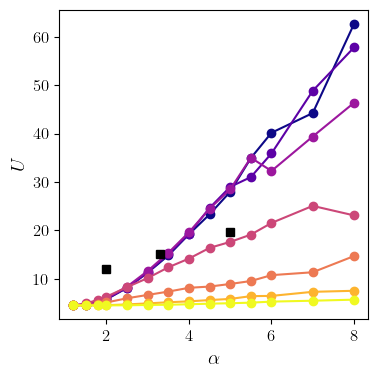

In [8]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.plasma
num_cofs = len(cofs)

# U_experimental = np.array([1.2512, 4.108, 5.747])
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

U_experimental = np.array([find_U_from_S2(s2) for s2 in S2_experimental])
print("U_experimental self consistent:", U_experimental)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            # eccentricity,
            aspect_ratios,
            Us_self_consistents[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    plt.plot(
        alpha_experimental,
        4/3*U_experimental/phi_experimental,
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    # plt.ylabel("$U  / (\\eta(\\phi) V_{{excl}}) $")#\\phi$")
    plt.ylabel("$U $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    # plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.ylim(0, 2)
    # plt.xlim(1.5, 6.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    # plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_unscaled.png", dpi=300, bbox_inches='tight')
    plt.show()

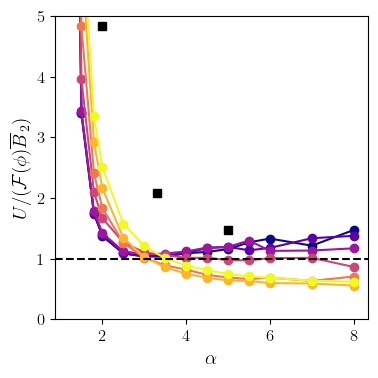

In [9]:
def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor

def parsons_volume_approx(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 /3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term

def parsons_volume_approx_p4(alpha):
    """
    Calculates the magnitude of the P4 coefficient 
    from the excluded volume expansion (Eq. 19).
    """
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    global_factor = 8.0 / np.sqrt(1.0 - chi**2)
    p4_factor = (1.0 / 35.0) * chi**4
    return global_factor * p4_factor

def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 /32 *np.pi *  (8*alpha / np.pi +2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi) 
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete +second_coeff_B_complete + second_coeff_C_complete)



U_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
    # volume_excluded = -second_coeff_excluded_volume(eccentricity)
    volume_excluded = parsons_volume_approx(aspect_ratios)

    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = phi_dense*(1-3/4*phi_dense) / (1-phi_dense)**2
        U_theoretical[i_cof, i_I, :] = volume_excluded * correction_density 
        # correction_density = phi_dense/24 *(4*phi_dense**2 - 33*phi_dense+34) / (1-phi_dense)**2
        plt.plot(
            # eccentricity,
            aspect_ratios,
            # U_fitted[i_cof, i_I, :] /(volume_excluded*correction_density), #factor 3/4 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
            Us_self_consistents[i_cof, i_I, :] / U_theoretical[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    plt.ylabel("$U  / (\\mathcal{{F}}(\\phi) \\overline{{B}}_{{2}}) $")#\\phi$")
    # plt.ylabel("$U  / \\phi) $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Excluded volume/2")
    plt.ylim(0, 5.0)
    # plt.xlim(1.5, 10.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.5, 1.1), fontsize=10)
    # plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_scaled.png", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_20561/2527741345.py:14: RuntimeWarning: invalid value encountered in sqrt
  alphas_jeffrey = np.sqrt((1 + beta_jeffrey) / (1-beta_jeffrey))


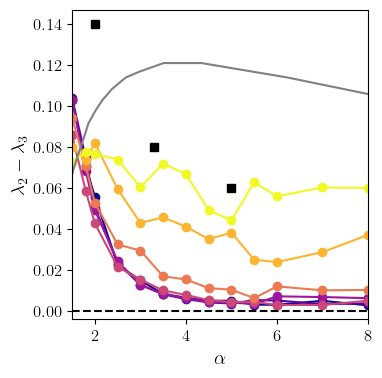

In [10]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

# load csv file
data_pure_jeffrey = np.loadtxt("biaxiality_jeffrey.csv", delimiter=",", skiprows=0) 

beta_jeffrey = data_pure_jeffrey[:, 0]
biaxiality_jeffrey = data_pure_jeffrey[:, 1]
alphas_jeffrey = np.sqrt((1 + beta_jeffrey) / (1-beta_jeffrey))

cmap = plt.cm.plasma
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot Jeffrey's prediction
    plt.plot(alphas_jeffrey, biaxiality_jeffrey, '-', color='gray', label="Jeffrey's prediction")

    # Plot experimental data
    plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    # plt.title(f"Biaxiality vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\lambda_2-\\lambda_3$")
    # plt.ylim(-0.0, 0.33)
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    # plt.axhline(0.5, color='k', linestyle=':', linewidth=1.5, label="Maximum biaxiality")  
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(2.0, 0.6), fontsize=10)
    # plt.grid(True)
    plt.tight_layout()
    plt.xlim(1.5, 8.0)
    plt.savefig(f"biaxiality_vs_alpha_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



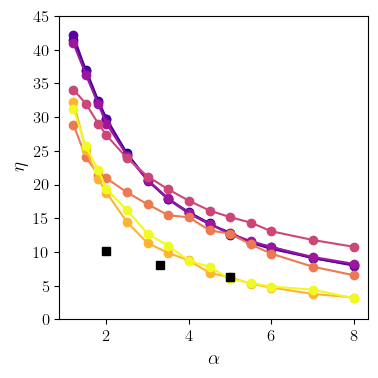

In [11]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
      
    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')


    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    # plt.grid(True)
    plt.ylim([0., 45])
    plt.tight_layout()
    plt.savefig(f"theta_d_vs_alpha_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



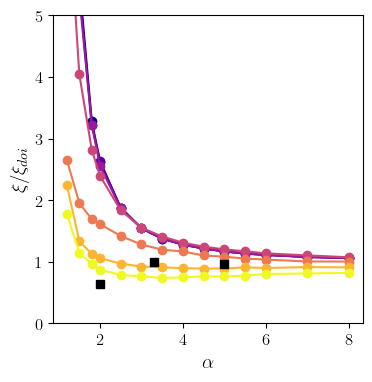

In [12]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        nematic_factor = (2+nematic_parameter[i_cof, i_I, :])/(3*nematic_parameter[i_cof, i_I, :])
        lambda_derived = beta * nematic_factor
        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            # ell/beta,
            ell/lambda_derived,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
        doi_theory_lambda = beta*(2 + nematic_parameter[i_cof, i_I, :]) 

    # plot experimental data
    eccentricity_experimental = np.sqrt(1 - 1 / alphas_rods_experiments**2)
    c_experimental = np.tan(np.deg2rad(theta_d_rods_experiments))**2
    ell_experimental = (+1 + c_experimental) / (1-c_experimental)
    beta_experimental = (alphas_rods_experiments**2 - 1) / (alphas_rods_experiments**2 + 1)
    nematic_factor_experimental = (2+S2_experimental)/(3*S2_experimental)
    lambda_derived_experimental = beta_experimental * nematic_factor_experimental
    plt.plot(
        alphas_rods_experiments,
        # ell_experimental/beta_experimental,
        ell_experimental/lambda_derived_experimental,
        's',
        color='black',
        label='Experiments (rods)'
    )    
    

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\xi / \\xi_{doi}$")
    # plt.legend(title="$\\mu_p =$")
    # plt.grid(True)
    plt.ylim([0., 5])
    # plt.tight_layout()
    plt.savefig(f"ericksen_number_vs_epsilon_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



/tmp/ipykernel_20561/743417487.py:2: RuntimeWarning: divide by zero encountered in divide
  first_factor = 15 / 32 / x**4
/tmp/ipykernel_20561/743417487.py:3: RuntimeWarning: divide by zero encountered in arctanh
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_20561/743417487.py:3: RuntimeWarning: invalid value encountered in multiply
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_20561/743417487.py:3: RuntimeWarning: invalid value encountered in divide
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_20561/743417487.py:4: RuntimeWarning: divide by zero encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
/tmp/ipykernel_20561/743417487.py:4: RuntimeWarning: invalid value encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))


Text(0.5, 1.0, 'Second coefficient of excluded volume as a function of eccentricity')

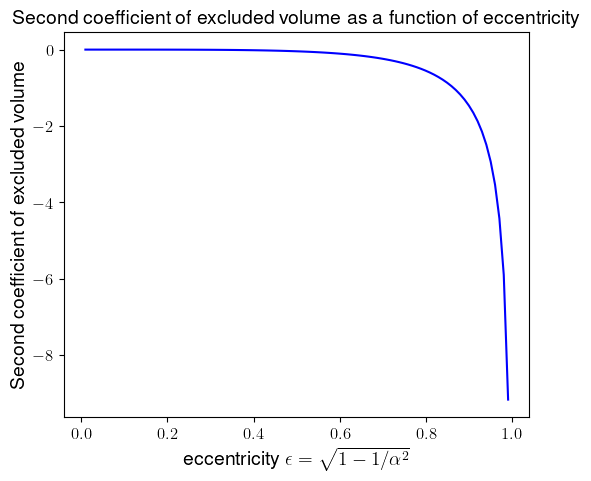

In [13]:
x = np.linspace(0, 1, 100)
plt.figure(figsize=(6, 5))
plt.plot(x, second_coeff_excluded_volume(x), label='Second coefficient of excluded volume', color='blue')
plt.xlabel('eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.ylabel('Second coefficient of excluded volume')
plt.title('Second coefficient of excluded volume as a function of eccentricity')


Text(0.5, 1.0, 'Eccentricity as a function of aspect ratio')

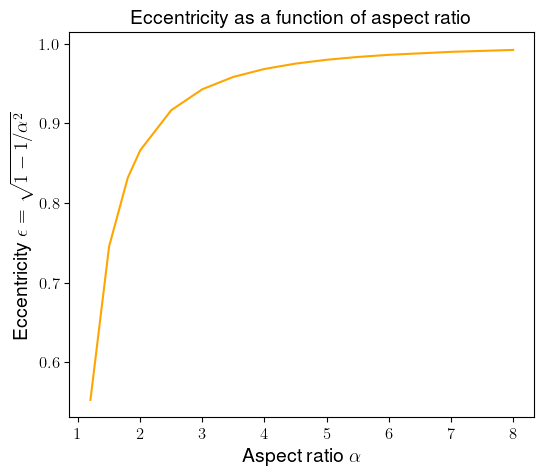

In [14]:
plt.figure(figsize=(6, 5))
plt.plot(aspect_ratios, eccentricity, label='Eccentricity', color='orange')
plt.xlabel('Aspect ratio $\\alpha$')
plt.ylabel('Eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.title('Eccentricity as a function of aspect ratio')

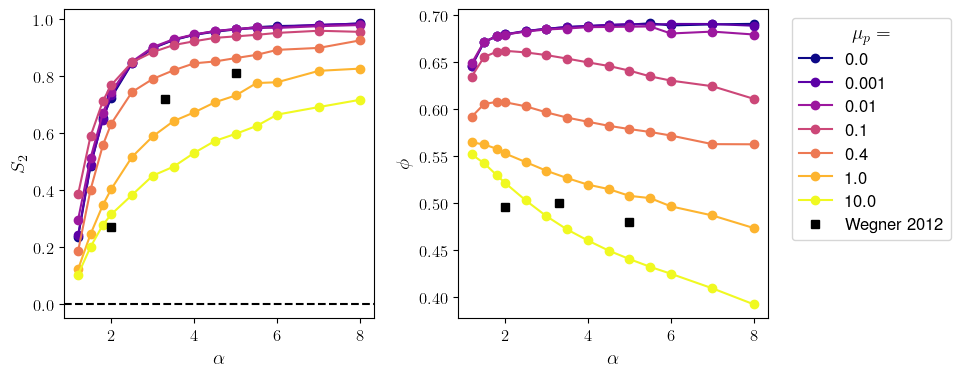

In [15]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[0].plot(
        aspect_ratios,
        nematic_parameter[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax[0].plot(alpha_experimental, S2_experimental, 's', label='Wegner 2012', color='black')
ax[1].plot(alpha_experimental, phi_experimental, 's', label='Wegner 2012', color='black')
ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$S_2$")
ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel(f"$\\alpha$")

ax[1].set_ylabel("$\\phi$")
fig.tight_layout()
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
plt.savefig(f"S2_phi_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')

Power law fit parameters: a = 1.0511905060445317, b = -2.317946937647289


<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_20561/240988389.py:43: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel("$6 \phi \\alpha^2 / \pi$")
/tmp/ipykernel_20561/240988389.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(n_ell_fit, power_law(n_ell_fit, *popt), 'k--', label='Power law fit (frictionless)', linewidth=3, color=colors[0])


Text(0, 0.5, '$D_{r}/ \\dot \\gamma$')

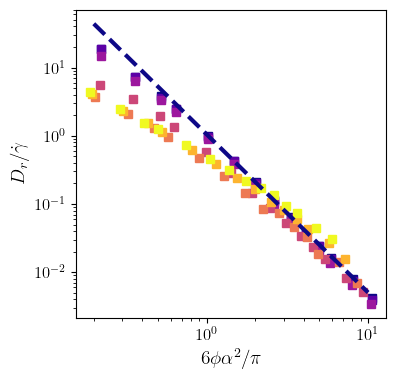

In [16]:
# Power law model: y = a * x^b
def power_law(x, a, c):
    return a *x**c

n_ell_fit = np.linspace(2*10**(-1), 10**1, 100)

# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
max_nell = 0
for i_cof, cof_val in enumerate(cofs):
    V_p = 4 * np.pi * aspect_ratios / 3  # particle volume for prolate ellipsoid
    n_ell3 = phis[i_cof, 0, :] / V_p *aspect_ratios**3
    nem_param = nematic_parameter[i_cof, 0, :]
    correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nem_param**2

    max_nell = max(max_nell, np.max(n_ell3))

    ax.loglog(
        n_ell3[:],
        D_r[i_cof, 0, :] * correction_end_end_contact[:]**2/shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof]
    )

    if cof_val == 0.0:
        # Fit the data
        popt, _ = spo.curve_fit(
            power_law,
            n_ell3[5:],
            D_r[0, 0, 5:] * correction_end_end_contact[5:]**2 / shear_rates[0, 0, 5:],
            p0=[0,0]  # Initial guess for a and b
        )
        

correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nematic_parameter[0,0,:]**2
ax.plot(n_ell_fit, power_law(n_ell_fit, *popt), 'k--', label='Power law fit (frictionless)', linewidth=3, color=colors[0])

# Plot

print(f"Power law fit parameters: a = {popt[0]}, b = {popt[1]}")

ax.set_xlabel("$6 \phi \\alpha^2 / \pi$")
ax.set_ylabel("$D_{r}/ \\dot \\gamma$")
# fig.savefig(f"D_r_over_shear_vs_n_ell3_I_{I}.png", dpi=300, bbox_inches='tight')

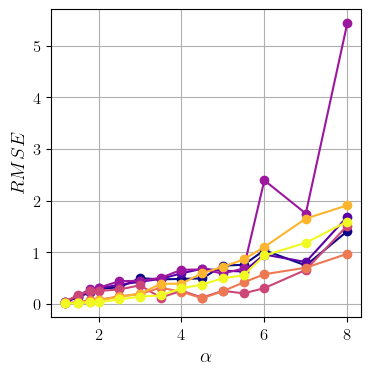

In [17]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        rmse_self_consistents[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$RMSE$")
ax.grid(True)
plt.savefig(f"rmse_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


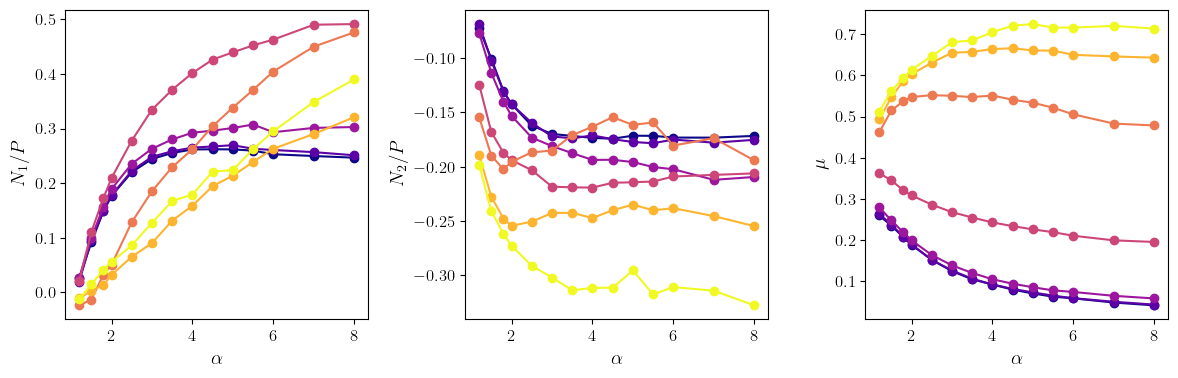

In [18]:
#plot n1_diff and n2_diff as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        n1_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[1].plot(
        aspect_ratios,
        n2_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[2].plot(
        aspect_ratios,
        p_xy[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )


ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$N_1/P$")
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$N_2/P$")
ax[2].set_xlabel(f"$\\alpha$")
ax[2].set_ylabel("$\\mu$")
fig.tight_layout()


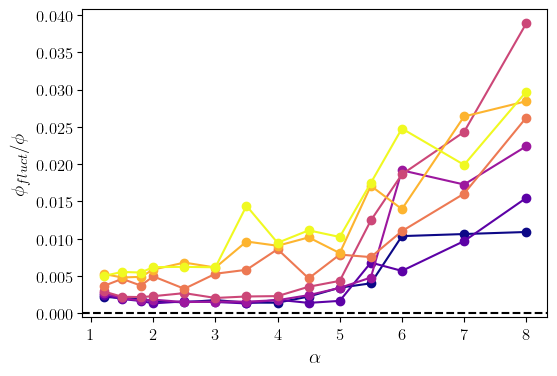

In [19]:
# plot fluctuations of phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        phi_fluctuations[i_cof, 0, :]/phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\phi_{fluct}/\\phi$")
ax.axhline(0.0, color='k', linestyle='--', linewidth=1.5)


Text(0.5, 0, '$\\alpha$')

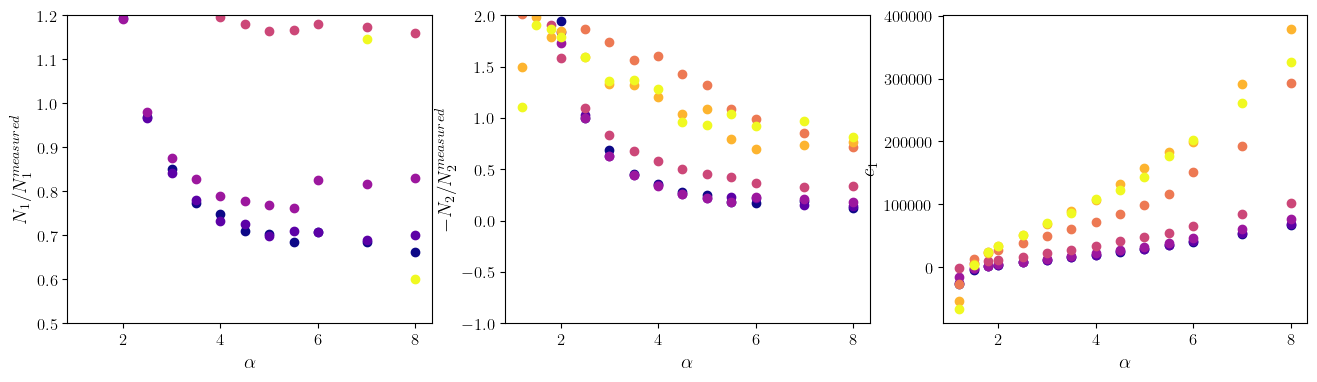

In [20]:
# for each alpha as a function of cof fit the stress with the pressure and then check the predicted N_1 and N_2 against the computed once

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i_cof, cof in enumerate(cofs):
    const_fits = np.zeros((len(aspect_ratios)))
    n1s_predicted = np.zeros((len(aspect_ratios)))
    n2s_predicted = np.zeros((len(aspect_ratios)))
    n1s_measured = np.zeros((len(aspect_ratios)))
    n2s_measured = np.zeros((len(aspect_ratios)))
    shear_stress_measured = np.zeros((len(aspect_ratios)))
    shear_stress_predicted = np.zeros((len(aspect_ratios)))

    for i_alpha, alpha in enumerate(aspect_ratios):
        n1_measured = n1_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        n2_measured = n2_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        phi_dense = phis[i_cof, 0, i_alpha]
        S2 = S2_tensor[i_cof, 0, i_alpha, :, :]
        S4 = S4_tensor[i_cof, 0, i_alpha, :, :, :, :]

        shear_rate = shear_rates[i_cof, 0, i_alpha]
        strain_tensor = 0.5*np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]]) * shear_rate 
        
        T1 = np.einsum('ijkl, kl->ij', S4, strain_tensor)  # 2nd order tensor
        T2 = np.einsum('ijkl, kl->ij', S4, S2)  
        T3 = S2@S2 
        T_elastic = -(T3 + phi_dense*S2/3 - T2)
        # const_fit = - p_yy[i_cof, 0, i_alpha] / total_stress[0, 0]
        # const_fits[i_alpha] = const_fit
        # stress_model = const_fit * total_stress

        b = np.array([
            p_yy[i_cof, 0, i_alpha],   # measured sigma_yy
            p_xy[i_cof, 0, i_alpha]    # measured sigma_xy
        ])

        A = np.array([
            [T1[1, 1], T_elastic[1, 1]],  # sigma_yy = row 1, col 1
            [T1[0, 1], T_elastic[0, 1]]   # sigma_xy = row 0, col 1 (symm)
        ])

        c1, c2 = np.linalg.solve(A, b)

        stress_model = c1 * T1 + c2 * T_elastic
        const_fits[i_alpha] = c1

        n1_predicted = (stress_model[0,0] - stress_model[1,1]) / p_yy[i_cof, 0, i_alpha]
        n2_predicted = (stress_model[1,1] - stress_model[2,2]) / p_yy[i_cof, 0, i_alpha] 

        n1s_predicted[i_alpha] = n1_predicted
        n2s_predicted[i_alpha] = n2_predicted
        n1s_measured[i_alpha] = n1_measured
        n2s_measured[i_alpha] = n2_measured
        shear_stress_measured[i_alpha] = p_xy[i_cof, 0, i_alpha]
        shear_stress_predicted[i_alpha] = stress_model[0, 1]

    # ax[0].plot(
    #     aspect_ratios,
    #     n1s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[1].plot(
    #     aspect_ratios,
    #     n2s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[2].plot(
    #     aspect_ratios,
    #     const_fits,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[3].plot(
    #     aspect_ratios,
    #     shear_stress_predicted,
    #     '-o',
    #     color=colors[i_cof],)

    ax[0].plot(
        aspect_ratios,
        n1s_predicted/n1s_measured,
        'o',
        color=colors[i_cof],)
    ax[1].plot(
        aspect_ratios,
        -n2s_predicted/ n2s_measured,
        'o',
        color=colors[i_cof],)
    ax[2].plot(
        aspect_ratios,
        const_fits,
        'o',
        color=colors[i_cof],)

ax[0].set_ylim(0.5, 1.2)
ax[1].set_ylim(-1, 2)
ax[0].set_ylabel("$N_1/N_1^{measured}$")
ax[1].set_ylabel("$-N_2/N_2^{measured}$")
ax[2].set_ylabel("$c_1$")
ax[0].set_xlabel("$\\alpha$")
ax[1].set_xlabel("$\\alpha$")
ax[2].set_xlabel("$\\alpha$")



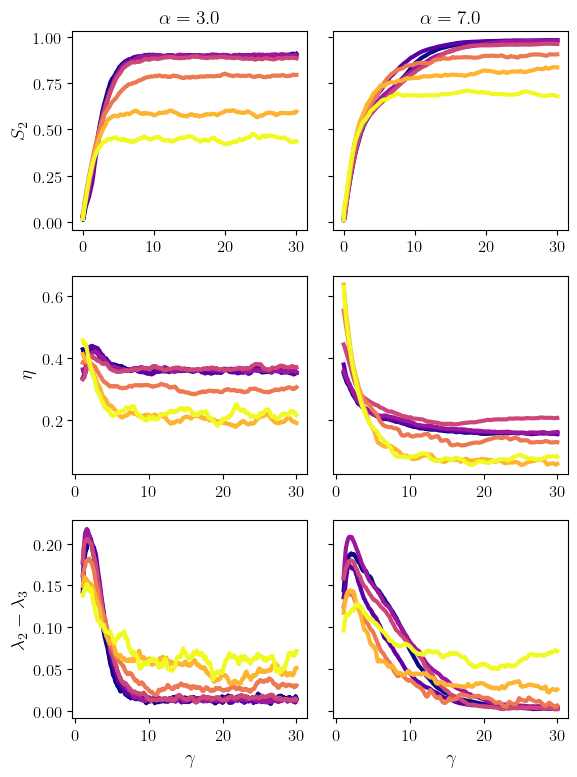

In [21]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5, 12]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(3, len(alpha_values), figsize=(3*len(alpha_values), 8), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        ax[0][i].plot(
            gamma,
            S2_t,
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[1][i].plot(
            gamma[100:],
            eta[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[2][i].plot(
            gamma[100:],
            biaxiality_t[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )


    ax[0, i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[2, i].set_xlabel("$\\gamma$")

ax[0, 0].set_ylabel("$S_2$")
ax[1, 0].set_ylabel("$\\eta$")
ax[2, 0].set_ylabel("$\\lambda_2 - \\lambda_3$")
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha.png", dpi=600, bbox_inches='tight')

<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20561/2713822681.py:49: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")


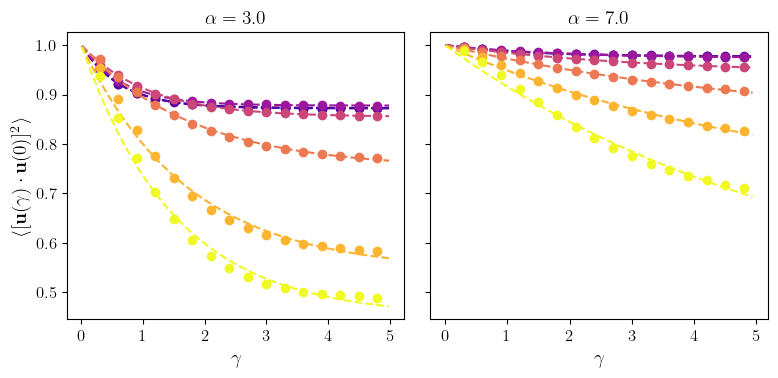

In [22]:
# plot oacf over time

def model_decay(t, tau_r, A_infty):
    return A_infty + (1 - A_infty) * np.exp(-t / tau_r)

alpha_indexs = [5, 12]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(4*n_plots, 4), sharey=True)


for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = cofs.index(cof_val)

        t = times[i_cof, 0, alpha_index, :]
        gamma = shear_rates[i_cof, 0, alpha_index] * t
        corr = oacf[i_cof, 0, alpha_index, :]

        t = np.where(t != 0, t, np.nan)  # Replace zeros with NaN for better plotting
        corr = np.where(corr != 0, corr, np.nan)  # Replace zeros with NaN for better plotting
        gamma = np.where(gamma != 0, gamma, np.nan)

        ax[i].plot(
            # t[::30],
            gamma[::30],
            corr[::30],
            'o',
            label=f"{cof_val}",
            color=colors_cof[i_cof]
            # linewidth = 2, 
        )
        # plot the fitted model
        ax[i].plot(
            gamma, 
            model_decay(gamma, tau_r[i_cof, 0, alpha_index]*shear_rates[i_cof, 0, alpha_index], A_infty[i_cof, 0, alpha_index]),
            color=colors_cof[i_cof],
            linestyle='--'
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    # ax[i].set_xlabel("$t$")
    ax[i].set_xlabel("$\\gamma$")

ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")
fig.tight_layout()
# fig.savefig(f"oacf_vs_time_alpha.svg", dpi=300, bbox_inches='tight')
fig.savefig(f"oacf_vs_strain_alpha.png", dpi=300, bbox_inches='tight')


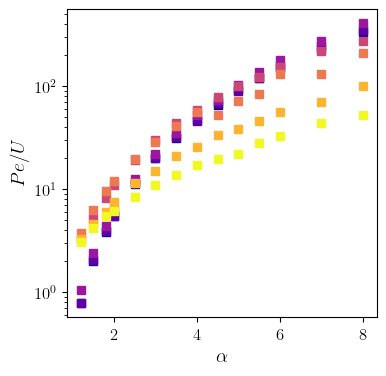

In [36]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.plot(
        aspect_ratios,
        Pe,  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$Pe$")
ax.set_yscale('log')
# ax.set_ylim(0, 100)
fig.savefig(f"Pe_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

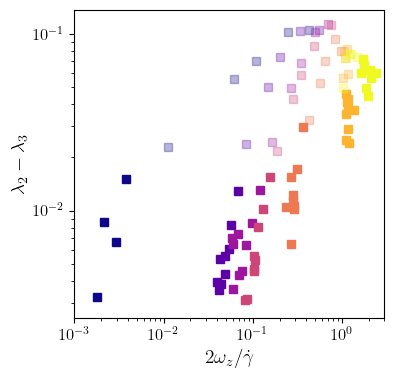

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.loglog(
        -2*omega[i_cof, 0, 5:, 2] *shear_rates[i_cof, 0, 5:] / np.sqrt(1-beta[5:]**2), 
        biaxiality[i_cof, 0, 5:],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

    ax.loglog(
        -2*omega[i_cof, 0, :5, 2] *shear_rates[i_cof, 0, :5] / np.sqrt(1-beta[:5]**2), 
        biaxiality[i_cof, 0, :5],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof], 
        alpha=0.3
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$2\\omega_z/ \\dot\\gamma$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
# ax.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Maximum biaxiality")
plt.xlim(0.001, 3.0)
# ax.set_ylim(0, 100)
fig.savefig(f"biaxiality_vs_omega.svg", dpi=300, bbox_inches='tight')

(0.0001, 0.5)

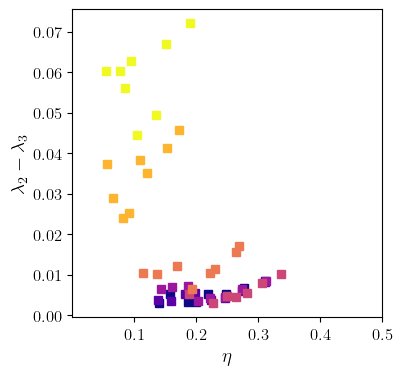

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
   
    ax.plot(
        theta_d[i_cof, 0, 6:],
        biaxiality[i_cof, 0, 6:],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\eta$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
plt.xlim(0.0001, 0.5)

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20561/1096965624.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")


Text(0, 0.5, '$2\\omega_z / D_r \\dot\\gamma $')

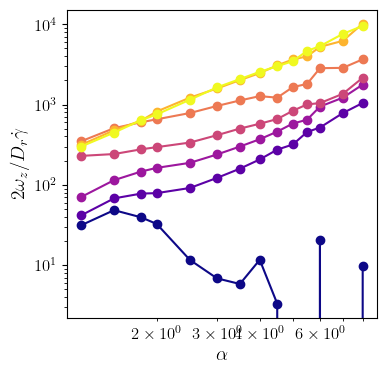

In [39]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

screening_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))

for i_cof, cof_val in enumerate(cofs):
    ax.loglog(
        aspect_ratios,
        # - 2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :] / np.sqrt(1 - beta**2), 
        - 2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :] / D_r[i_cof, 0, :], 
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    screening_omega[i_cof, 0, :] = - 2*omega[i_cof, 0, :, 2] / np.sqrt(1 - beta**2)

ax.set_xlabel(f"$\\alpha$")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")
# ax.grid(True)
# plt.savefig(f"omega_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')


<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:54: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20561/2646640204.py:54: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")


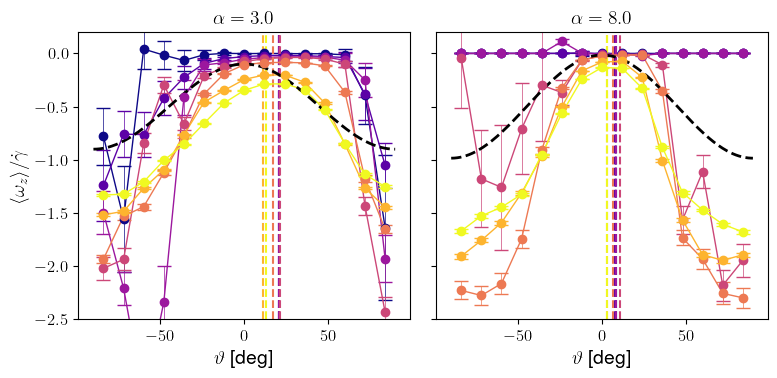

In [27]:
alpha_indexs = [5, 13]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(4*n_plots, 4), sharey=True)

if len(alpha_indexs) == 1:
    ax = [ax]  # Make ax iterable


for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = cofs.index(cof_val)

        thetas = theta_bins[i_cof, 0, alpha_index, :] * 180/np.pi
        omega_theta = omega_bins[i_cof, 0, alpha_index, :]
        std_omega_theta = std_omega_bins[i_cof, 0, alpha_index, :]
        ax[i].plot(
            thetas,
            omega_theta,
            '-',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 1.0, 
        )
        ax[i].errorbar(thetas, omega_theta, std_omega_theta, mfc=colors_cof[i_cof],mec=colors_cof[i_cof],
                ecolor=colors_cof[i_cof], fmt='o', capsize=5, linestyle='None', linewidth=0.5)
        ax[i].axvline(theta_d[i_cof, 0, alpha_index]*180/np.pi, color=colors_cof[i_cof], linestyle='--', label="$\\eta$")

        

        ax[i].set_ylim(-2.5, 0.2)
        
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 200)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
    theta_fit = theta_fit * 180/np.pi
    

    ax[i].plot(
        theta_fit,
        jeffrey_omega,
        'k--',
        label='Jeffrey',
        linewidth=2
    )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[i].set_xlabel("$\\vartheta$ [deg]")
    
ax[0].set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin_mup0.svg", dpi=300, bbox_inches='tight')


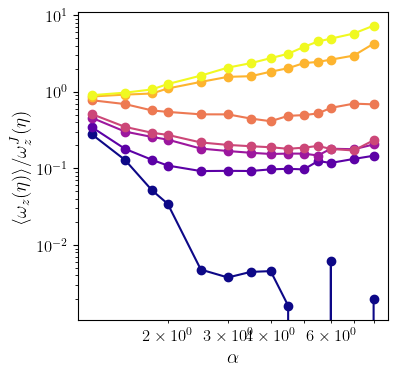

In [28]:


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ratio_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))


for i_cof, cof_val in enumerate(cofs):
    theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])

    for j, alpha in enumerate(aspect_ratios):
        beta = (alpha**2 - 1) / (alpha**2 + 1)

        thetas = theta_bins[i_cof, 0, j, :]
        omega_theta = omega_bins[i_cof, 0, j, :]
        std_omega_theta = std_omega_bins[i_cof, 0, j, :]

        value_at_eta = np.interp(theta_shifted[j], thetas, omega_theta)

        jeffrey_value_at_eta = -(1 - beta * np.cos(2 * theta_shifted[j])) / 2

        ratio_omega[i_cof, 0, j] = value_at_eta / jeffrey_value_at_eta

    ax.loglog(
        aspect_ratios,
        ratio_omega[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega_z(\\eta) \\rangle / \\omega_z^{{J}}(\\eta)$")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"omega_vs_jeffrey_at_eta_{I}.png", dpi=300, bbox_inches='tight')

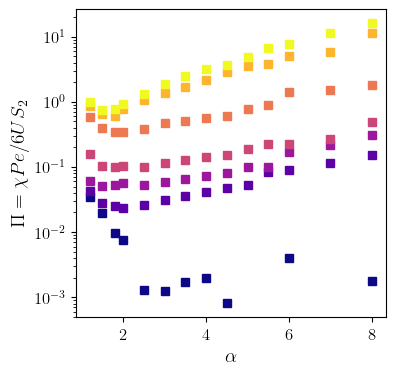

In [29]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
Pis = np.zeros((len(cofs), 1, len(aspect_ratios)))
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :]) * ratio_omega[i_cof, 0, :] / nematic_parameter[i_cof, 0, :]
    shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    Pis[i_cof, 0, :] = Pe/(6*Us_self_consistents[i_cof, 0, :])
    # Pis[i_cof, 0, :] = Pe/(6*U_fitted[i_cof, 0, :])
    # Pis[i_cof, 0, :] = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :]) * ratio_omega[i_cof, 0, :]
    ax.plot(
        aspect_ratios,
        # Pe/(6*U_fitted[i_cof, 0, :]),
        Pis[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\alpha$")
# ax.set_ylabel("$\\chi Pe/ 6 U S_2$")
ax.set_ylabel("$\\Pi = \\chi Pe/ 6 U S_2$")
ax.set_yscale('log')
fig.savefig(f"Pe_screened_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')

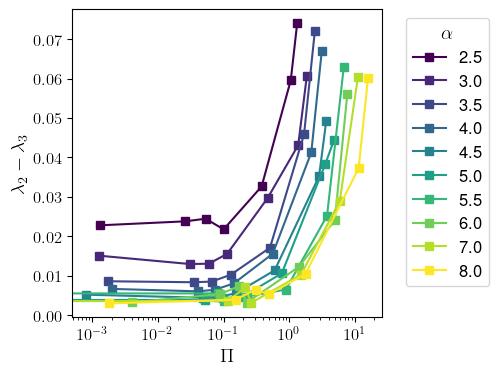

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)

large_aspect_ratios = aspect_ratios[aspect_ratios >= 2.5]
cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(large_aspect_ratios) - 1)) for i in range(len(large_aspect_ratios))]

for i_alpha, alpha in enumerate(large_aspect_ratios):
    i_alpha2 = np.where(aspect_ratios == alpha)[0][0]
    ax.semilogx(
        Pis[:, 0, i_alpha2],
        biaxiality[:, 0, i_alpha2],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's-',
        label=f"{alpha}",
        color=colors_alpha[i_alpha]
    )

# for i_cof, cof_val in enumerate(cofs):
#     print(f"cof: {cof_val}")
#     ax.loglog(
#         Pis[i_cof, 0, -1:],
#         biaxiality[i_cof, 0, -1:],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
#         's',
#         label=f"{cof_val}",
#         color=colors_cof[i_cof]
#     )
#     ax.loglog(
#         Pis[i_cof, 0, :5],
#         biaxiality[i_cof, 0, :5],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
#         's',
#         label=f"{cof_val}",
#         color=colors_cof[i_cof], 
#         alpha=0.2
#     )
ax.legend(title="$\\alpha$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
ax.set_xlabel("$\\Pi$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
# ax.set_xlim(0.001, 10)
plt.savefig(f"biaxiality_vs_Pi.pdf", dpi=300, bbox_inches='tight')

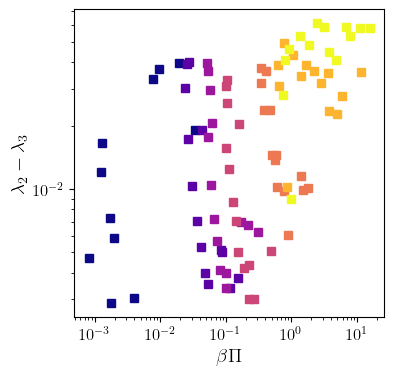

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
   
    ax.loglog(
        Pis[i_cof, 0, :],
        beta[:]*biaxiality[i_cof, 0, :],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
    
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\beta \\Pi$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
plt.savefig(f"biaxiality_vs_betaPi.png", dpi=300, bbox_inches='tight')

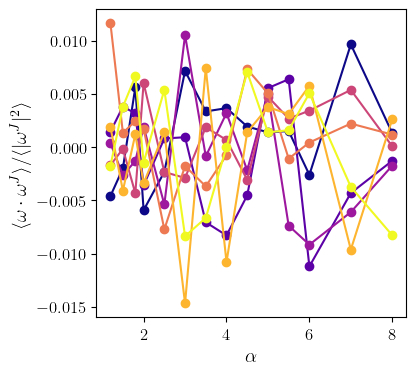

In [32]:


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for i_cof, cof_val in enumerate(cofs):
   
    ax.plot(
        aspect_ratios,
        screening_jeffrey[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega \\cdot \\omega^J \\rangle / \\langle |\\omega^J|^2 \\rangle $")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"corelation_full_{I}.png", dpi=300, bbox_inches='tight')

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20561/2874984403.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")


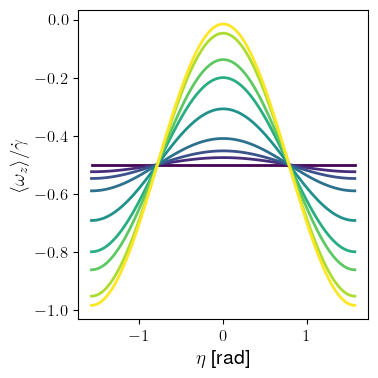

In [33]:
alpha_values = np.array([1.00, 1.05, 1.1, 1.2, 1.5, 2.0, 2.5, 4.5, 8.0])
cmap = plt.cm.viridis
colors_alpha = [cmap(i / (len(alpha_values) - 1)) for i in range(len(alpha_values))]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

thetas = np.linspace(-np.pi/2, np.pi/2, 200)
for i, alpha_index in enumerate(alpha_values):
    
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 100)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
        
    ax.plot(
        theta_fit,
        jeffrey_omega,
        color=colors_alpha[i],
        label='Jeffrey',
        linewidth=2
    )

    ax.set_xlabel("$\\eta$ [rad]")
    
ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin_pure_jeffrey.svg", dpi=300, bbox_inches='tight')


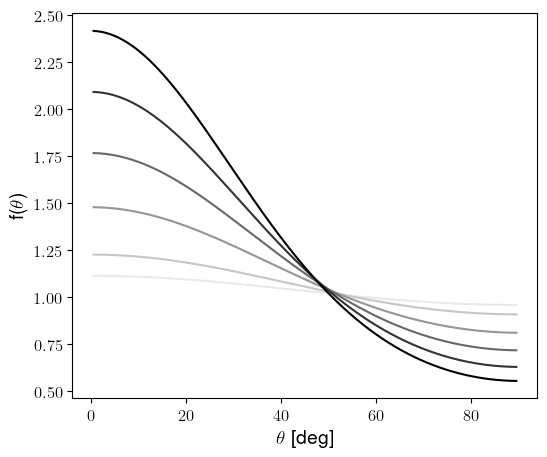

In [34]:
# plot a generic maier saupe distribution for different S2 values

plt.figure(figsize=(6, 5))
thetas = np.linspace(0.01, np.pi/2-0.01, 200)

S2_values = [0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.98]

cmap = plt.cm.Grays

colors_S2 = [cmap(i / (len(S2_values) - 1)) for i in range(len(S2_values))]
for i, S2 in enumerate(S2_values):
    exponent = (3 * np.cos(thetas)**2 - 1) * S2 / 2
    distribution = np.exp(exponent)
    distribution /= np.trapezoid(distribution*np.sin(thetas), thetas)  # Normalize the distribution

    plt.plot(thetas*180/np.pi, distribution, label=f"$S_2 = {S2}$", color=colors_S2[i])

plt.xlabel("$\\theta$ [deg]")
plt.ylabel("f($\\theta$)")
plt.savefig(f"maier_saupe_distribution.svg", dpi=300, bbox_inches='tight')

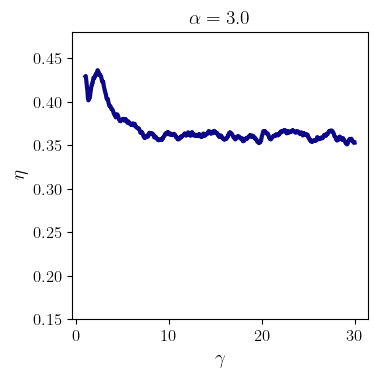

In [35]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(1, len(alpha_values), figsize=(4*len(alpha_values), 4), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        if cof_val <= 0.0:

            ax.plot(
                gamma[100:],
                eta[100:],
                label=f"{cof_val}",
                color=colors_cof[i_cof],
                linewidth = 3, 
                # marker='o'
            )


    ax.set_title(f"$\\alpha = {alpha_values[i]}$")
    ax.set_xlabel("$\\gamma$")

# ax[0, 0].set_ylabel("$S_2$")
ax.set_ylabel("$\\eta$")
# ax.set_ylabel("$\\lambda_2 - \\lambda_3$")
ax.set_ylim([0.15, 0.48])
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha_mup0.svg", dpi=600, bbox_inches='tight')